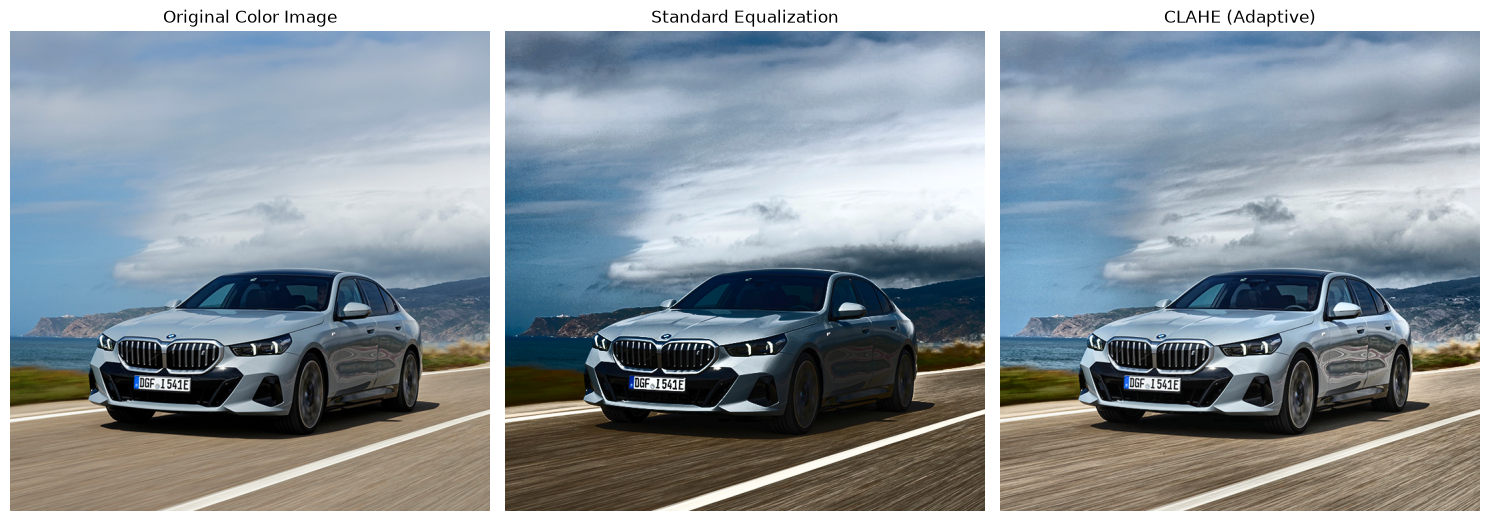

In [4]:
import cv2
import matplotlib.pyplot as plt

def process_color_image(image_path):
    # 1. Read the image
    # OpenCV loads images in BGR format by default
    bgr_img = cv2.imread(image_path)
    if bgr_img is None:
        print("Error: Could not load image. Check the file path.")
        return

    # Convert original to RGB for matplotlib visualization
    original_rgb = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)

    # 2. Convert to LAB Color Space
    lab_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2LAB)
    
    # Split into L, A, and B channels
    l_channel, a_channel, b_channel = cv2.split(lab_img)

    # 3. Standard Global Histogram Equalization (on L channel only)
    l_eq = cv2.equalizeHist(l_channel)
    # Merge back and convert to RGB for plotting
    lab_eq = cv2.merge((l_eq, a_channel, b_channel))
    standard_eq_rgb = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)

    # 4. CLAHE (on L channel only)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l_channel)
    # Merge back and convert to RGB for plotting
    lab_clahe = cv2.merge((l_clahe, a_channel, b_channel))
    clahe_rgb = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

    # --- Visualization Setup ---
    images = [original_rgb, standard_eq_rgb, clahe_rgb]
    titles = ['Original Color Image', 'Standard Equalization', 'CLAHE (Adaptive)']

    plt.figure(figsize=(15, 6))

    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage (replace with your actual file path)
process_color_image('BMW.jpeg')